# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

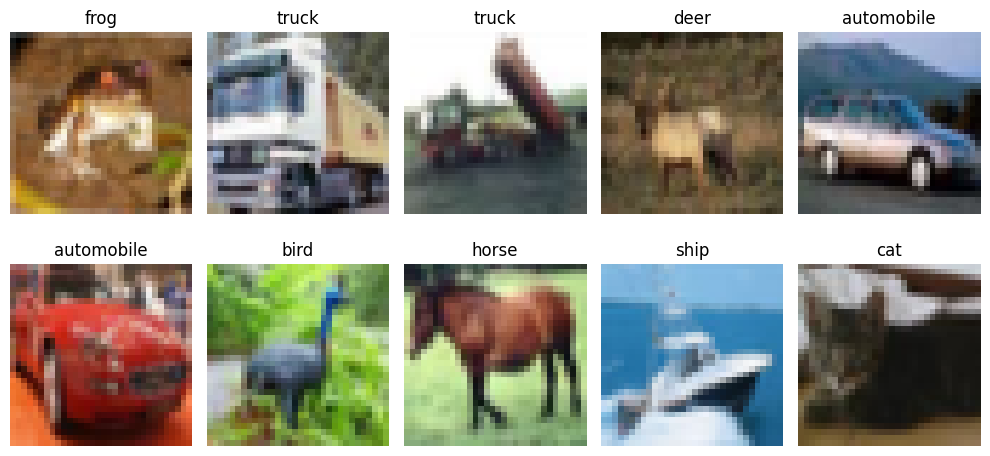

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

## ⏹️ Early Stopping Configuration

We configure an EarlyStopping callback to monitor the validation loss during training. If the validation loss does not improve for 3 consecutive epochs, training stops automatically and the model restores the best weights.

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.2406 - loss: 2.0383 - val_accuracy: 0.3228 - val_loss: 1.8517
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.2995 - loss: 1.8986 - val_accuracy: 0.3346 - val_loss: 1.8334
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3190 - loss: 1.8543 - val_accuracy: 0.3620 - val_loss: 1.7987
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3276 - loss: 1.8377 - val_accuracy: 0.3714 - val_loss: 1.7830
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3379 - loss: 1.8063 - val_accuracy: 0.3796 - val_loss: 1.7467
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3478 - loss: 1.7862 - val_accuracy: 0.3770 - val_loss: 1.7496
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3558 - loss: 1.7662 - val_accuracy: 0.3912 - val_loss: 1.7232
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3621 - loss: 1.7502 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4264 - loss: 1.6577
ANN Test Accuracy: 0.42640000581741333


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 113ms/step - accuracy: 0.4622 - loss: 1.5077 - val_accuracy: 0.5570 - val_loss: 1.2569
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.5985 - loss: 1.1411 - val_accuracy: 0.5554 - val_loss: 1.3740
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.6627 - loss: 0.9694 - val_accuracy: 0.6728 - val_loss: 0.9276
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.7039 - loss: 0.8455 - val_accuracy: 0.6638 - val_loss: 0.9690
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 112ms/step - accuracy: 0.7370 - loss: 0.7483 - val_accuracy: 0.6624 - val_loss: 1.0270
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 110ms/step - accuracy: 0.7662 - loss: 0.6685 - val_accuracy: 0.7270 - val_loss: 0.8155
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 113ms/step - accuracy: 0.7885 - loss: 0.6013 - val_accuracy: 0.6928 - val_loss: 0.9279
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.8071 - loss: 0

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7036 - loss: 0.8690
CNN Test Accuracy: 0.7035999894142151


# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 87ms/step - accuracy: 0.3780 - loss: 1.7139 - val_accuracy: 0.4802 - val_loss: 1.4355
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - accuracy: 0.4792 - loss: 1.4525 - val_accuracy: 0.5406 - val_loss: 1.3054
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 86ms/step - accuracy: 0.5122 - loss: 1.3619 - val_accuracy: 0.5942 - val_loss: 1.1277


In [ ]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Test Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4756 - loss: 1.4400
Augmented CNN Test Accuracy: 0.475600004196167


## 📈 Compare Learning Curves

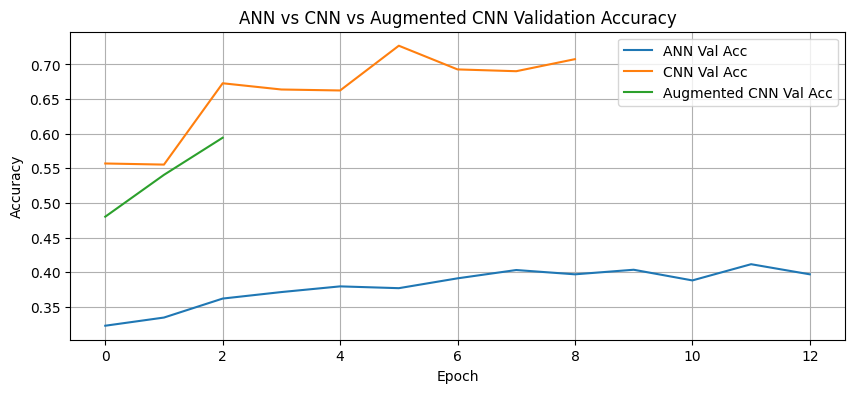

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.plot(aug_history.history['val_accuracy'], label='Augmented CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN vs Augmented CNN Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN",
        "Augmented CNN"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_test_acc
    ]
})

comparison

,Model,Test Accuracy
0,ANN,0.4264
1,CNN,0.7036
2,Augmented CNN,0.4756


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**